# AV Blocking Incidents: Frequency, Hazard Classification, and

Risk-Matrix Placement

Primary analysis notebook. It reads the raw DEM workbooks in `data/`,
runs every step of the analysis, and exports figures, tables, and key
numbers to `project-site/assets/` and `project-site/_variables.yml`,
which the Quarto paper and slides reference. Re-running this notebook
top to bottom regenerates all of them.

**Data credit.** The incident log comes from the San Francisco
Department of Emergency Management (DEM). Dr. Missy Cummings did most of
the difficult original cleaning and coding of these records; this
analysis builds on that work.

**Sections**

1.  Data loading, cleaning, and quality
2.  Data engineering from the secondary sheets
3.  Descriptive statistics
4.  Hazard taxonomy and narrative classification
5.  Impact (consequence) scoring
6.  Frequency estimation
7.  Is anything changing over time? (non-parametric trend tests)
8.  Risk matrix
9.  Sensitivity analysis

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from av_blocking import analysis, config, data, frequency as fq, nlp, plotting as P
from av_blocking import risk_matrix as rm, severity as sv, taxonomy as tx, trends as tr
from av_blocking.export import save_fig, save_table, save_text, save_var, save_vars

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200, "display.max_colwidth", 110, "display.max_columns", 40)
P.set_style()
config.VARIABLES_FILE.unlink(missing_ok=True)   # rebuild the paper's variables from scratch

def r(x, d=2):
    return float(round(float(x), d))

def fmt_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.3f}"

HAZ_LABEL = {h.code: f"{h.code} {h.short}" for h in tx.HAZARDS}

## 1. Data loading, cleaning, and quality

The primary source is the `DEM Incidents` sheet of
`AV-Brick-Report.xlsx`. Cleaning steps (all in `av_blocking.data`):

-   Start/clear times arrive as a mix of Excel time objects and `"H:MM"`
    strings. Both are parsed to minutes after midnight.
-   Duration is computed as clear minus start, **modulo 1,440 minutes**,
    so events that cross midnight come out positive. The workbook’s own
    formula did this for only some rows.
-   Narratives have their whitespace normalized and are flagged when
    missing or likely **truncated**. Many were cut at about 45–60
    characters by the export.
-   The operator (Waymo or Zoox) is extracted from the narrative. A
    missing AV count is treated as “at least one” for the clustering
    rule.

In [2]:
df = analysis.prepare()
days = data.observation_days()
T = float(days.sum())
w = df[df["in_covered_window"]].copy()     # incidents inside fully covered months

quality = pd.DataFrame({
    "Quantity": ["Incidents (primary sheet)", "Date range", "Months present",
                 "Covered months used for rates", "Covered exposure (days)",
                 "Incidents in covered months", "Narrative missing", "Narrative likely truncated",
                 "AV count missing", "Durations crossing midnight", "Operator = Waymo / Zoox / unstated"],
    "Value": [len(df), f"{df.date.min():%Y-%m-%d} to {df.date.max():%Y-%m-%d}",
              ", ".join(sorted(df.month.unique())), ", ".join(days.index), int(T), len(w),
              int(df.narrative_missing.sum()),
              f"{int(df.narrative_truncated.sum())} ({df.narrative_truncated.mean():.0%})",
              int(df.n_avs_missing.sum()), int(df.crosses_midnight.sum()),
              " / ".join(str(int((df.operator == o).sum())) for o in ["Waymo", "Zoox", "Unknown"])],
})
display(quality)
save_table(quality, "tbl-data-quality", "Data inventory and quality checks for the primary DEM sheet.")
save_vars({"n_incidents": len(df), "n_window": len(w), "window_days": int(T),
           "first_date": f"{df.date.min():%B %-d, %Y}", "last_date": f"{df.date.max():%B %-d, %Y}",
           "n_truncated": int(df.narrative_truncated.sum()),
           "pct_truncated": f"{df.narrative_truncated.mean():.0%}",
           "n_missing_narrative": int(df.narrative_missing.sum()),
           "n_months_covered": len(days)}, "data")

**Coverage gaps matter.** February has only three incidents, all on Feb
1–3, and April–May are missing entirely. Those are gaps in the log, not
months with no incidents. Rates and trends therefore use only the six
fully covered months (March and June–October, 184 days). The three
February incidents still count toward the classification and impact
analysis. Section 9 shows that the conclusions hold if February is
included.

In [3]:
print(df.groupby("month").agg(n=("incident_id", "size"), first=("date", "min"), last=("date", "max"),
                              truncated=("narrative_truncated", "mean")).round({"truncated": 2}))

          n      first       last  truncated
month                                       
2025-02   3 2025-02-01 2025-02-03       0.00
2025-03  24 2025-03-01 2025-03-30       0.96
2025-06  17 2025-06-03 2025-06-27       1.00
2025-07  18 2025-07-07 2025-07-25       1.00
2025-08  25 2025-08-01 2025-08-31       0.16
2025-09  11 2025-09-11 2025-09-30       0.18
2025-10  25 2025-10-05 2025-10-31       0.76

## 2. Data engineering from the secondary sheets

`AV-Brick-Report-analyzed.xlsx` adds:

| Sheet | Useful content | How it is used here |
|------------------------|------------------------|------------------------|
| `DEM Incidents` (analyzed copy) | AV-company ETA, other parties, emergency-responder-impact and transit-impact flags; 8 extra incidents with narratives but no times | Joined on (date, location): all 123 primary rows match. Extra incidents feed a frequency sensitivity check. |
| `DEM Incidents Quant` | Hand-coded neighborhood zone (1–10), multi-AV flag, 4-hour time-of-day bin, \>20 / \>40-minute flags | Neighborhood joined (119/123 match). The other derived columns are recomputed from source fields. |
| `plots and stats` | Monthly duration mean/SD/median, a 6-group skewness/normality/rank-sum table (a Kruskal–Wallis setup), and a March-vs-October Mann–Whitney test (W = 377, p = 0.063) | Replicated in Section 7, then extended with trend-specific tests. |

The analyzed sheet’s emergency-responder flag marks *responder
involvement* (for example, police called to direct traffic around a
stalled AV), not obstruction of an emergency response. So it is kept as
a separate feature and does not define hazard H2.

In [4]:
supp = data.supplementary_incidents()
eng = pd.DataFrame({
    "Feature": ["Neighborhood zone assigned", "ETA provided by AV company", "Emergency-responder flag = Y",
                "Transit-impact flag = Y", "Supplementary incidents (narrative, no times)"],
    "Count": [int((df.zone.notna()).sum()), int(df.eta_min.notna().sum()), int(df.er_impact_flag.sum()),
              int(df.transit_impact_flag.sum()), len(supp)],
})
display(eng)
print("ETA (minutes) when given:", df.eta_min.describe().round(1).to_dict())
display(supp)
save_var("data.n_supplementary", len(supp))

ETA (minutes) when given: {'count': 22.0, 'mean': 17.1, 'std': 11.0, 'min': 1.0, '25%': 12.0, '50%': 14.5, '75%': 20.0, 'max': 45.0}

## 3. Descriptive statistics

In [5]:
dur = w["duration_min"]
med, med_lo, med_hi = tr.bootstrap_median_ci(dur)
desc = pd.DataFrame({
    "Statistic": ["n", "Mean", "SD", "Median (bootstrap 95% CI)", "IQR", "90th percentile", "Max",
                  "Share > 20 min", "Share > 40 min", "Share >= 60 min", "Multi-AV incidents"],
    "Duration (minutes)": [len(dur), f"{dur.mean():.1f}", f"{dur.std():.1f}",
                           f"{med:.0f} ({med_lo:.0f}-{med_hi:.0f})",
                           f"{dur.quantile(.25):.0f}-{dur.quantile(.75):.0f}", f"{dur.quantile(.9):.0f}",
                           f"{dur.max():.0f}", f"{(dur > 20).mean():.0%}", f"{(dur > 40).mean():.0%}",
                           f"{(dur >= 60).mean():.0%}", f"{int(w.multi_av.sum())} ({w.multi_av.mean():.0%})"],
})
display(desc)
save_table(desc, "tbl-duration-summary", "Summary statistics for incident duration (covered months, n = 120).")
save_vars({"median": int(med), "median_lo": int(med_lo), "median_hi": int(med_hi), "mean": r(dur.mean(), 1),
           "p90": int(dur.quantile(.9)), "max": int(dur.max()), "iqr_lo": int(dur.quantile(.25)),
           "iqr_hi": int(dur.quantile(.75)), "pct_ge60": f"{(dur >= 60).mean():.0%}",
           "pct_multi": f"{w.multi_av.mean():.0%}", "n_multi": int(w.multi_av.sum())}, "dur")

by_month = w.groupby("month")["duration_min"].agg(n="size", mean="mean", sd="std", median="median").round(1)
by_month["incidents_per_30d"] = (by_month["n"] / days * 30).round(1)
display(by_month)
save_table(by_month.reset_index(), "tbl-monthly", "Incidents and duration by covered month.")

PosixPath('/home/jon/Documents/grad_school/ai-risk/AV_Brick/project-site/assets/tables/tbl-monthly.md')

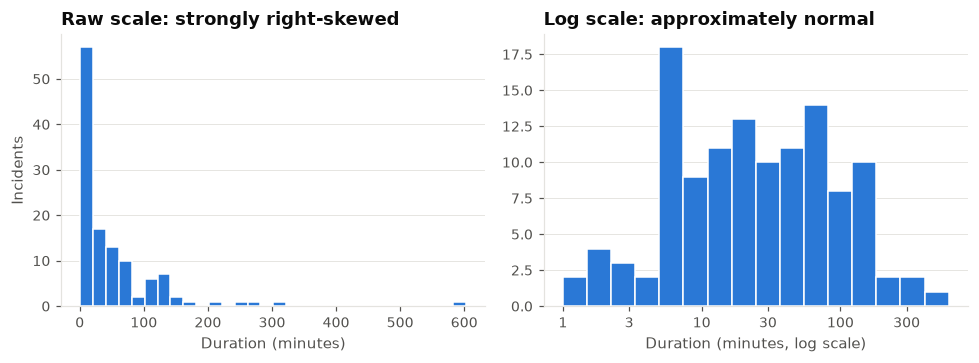

In [6]:
fig, _ = P.duration_distribution_plot(w["duration_min"])
save_fig(fig, "fig-duration-dist"); plt.show()
display(tr.normality(w["duration_min"]).round(4))

Raw durations are strongly right-skewed and heavy-tailed: skewness ≈
3.9, excess kurtosis ≈ 22, Shapiro–Wilk p \< 10⁻¹⁵. Log-durations look
approximately normal (Shapiro–Wilk p ≈ 0.38). Durations are therefore
close to log-normal. Rank-based tests are the primary inference, and
tests on log-durations serve as a parametric cross-check.

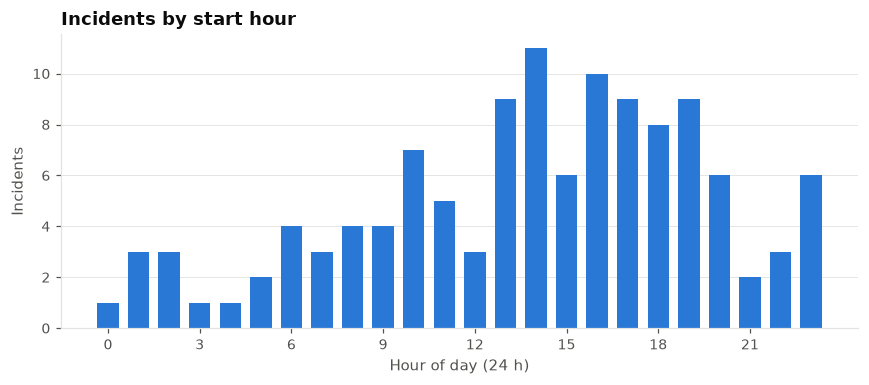

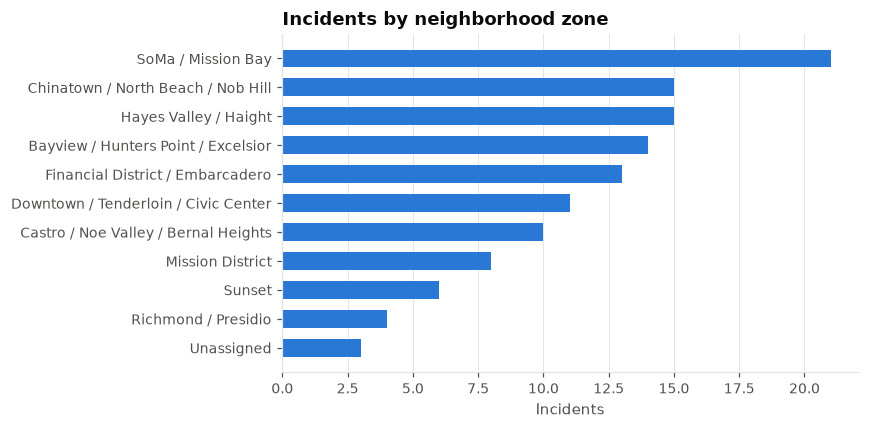

Weekday uniformity chi-square p = 0.565
Hour-of-day uniformity over 6 x 4-h bins p = < 0.001

In [7]:
hours = w["start_hour"].value_counts().reindex(range(24), fill_value=0)
fig, ax = P.count_bar_plot(hours, "Incidents by start hour", "Hour of day (24 h)")
ax.set_xticks(range(0, 24, 3), range(0, 24, 3))
save_fig(fig, "fig-hour"); plt.show()

nb = w["neighborhood"].value_counts()
fig, _ = P.count_bar_plot(nb, "Incidents by neighborhood zone", "", horizontal=True, figsize=(8, 4))
save_fig(fig, "fig-neighborhood"); plt.show()

wd = w["weekday"].value_counts().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
                                          "Saturday", "Sunday"], fill_value=0)
from scipy import stats
print("Weekday uniformity chi-square p =", round(stats.chisquare(wd).pvalue, 3))
print("Hour-of-day uniformity over 6 x 4-h bins p =",
      fmt_p(stats.chisquare(w["start_hour"].dropna().astype(int).floordiv(4).value_counts()
                            .reindex(range(6), fill_value=0)).pvalue))

## 4. Hazard taxonomy and narrative classification

### 4.1 Taxonomy design

A **hazard** here is defined by its *consequence*: what the immobilized
AV obstructed or put at risk. Two principles make the classes
defensible:

1.  **Separate consequence from cause.** Why the AV stopped (vehicle
    fault, signal outage, passenger, routing edge case) is recorded on a
    separate *contributing-cause* axis. Mixing the two axes produces
    overlapping, non-comparable categories.
2.  **Mutually exclusive and exhaustive by precedence.** An incident can
    match several descriptions, for example a fire scene that also has
    two AVs stuck. Each incident takes the *most severe* matching class
    (H1 \> H2 \> … \> H7), and H7 is the default. Every incident then
    counts exactly once, and frequencies add up to the total.

H6 (multi-AV clustering) is a hazard class in its own right because
simultaneous immobilization of several AVs at one site points to a
**common-mode (fleet-level) failure**: shared software, maps, or
connectivity. That is a different mechanism from a single vehicle’s
fault, with a disproportionate loss of road capacity.

In [8]:
tax = tx.taxonomy_table()
display(tax)
save_table(tax, "tbl-taxonomy", "Consequence-based hazard taxonomy (assigned by severity-first precedence).")
causes = pd.DataFrame(list(tx.CAUSES.items()), columns=["Code", "Contributing cause"])
display(causes)
save_table(causes, "tbl-causes", "Contributing-cause codes (mechanism axis).")

PosixPath('/home/jon/Documents/grad_school/ai-risk/AV_Brick/project-site/assets/tables/tbl-causes.md')

### 4.2 Method selection

| Approach | Needs | Fit for this data |
|------------------------|------------------------|------------------------|
| Keyword / regex rules over dispatcher shorthand | Domain reading only | **Selected.** Transparent, auditable, deterministic, and works on truncated text. |
| Supervised TF-IDF + logistic regression / XGBoost | Labeled training data, ideally hundreds per class | Evaluated below. With 4–17 examples in the rare classes it cannot learn them. |
| Fine-tuned transformer (BERT-type) | Even more labeled data | Not justified at n = 123. It would overfit, and the result would not be auditable. |
| Zero-shot NLI transformer | No labels; large model | Evaluated as an independent cross-check (optional extra). |

To evaluate any method, an independent reference is needed. Every
narrative was read and hand-coded
(`data/labels/manual_hazard_labels.csv`, with notes on ambiguous cases).

In [9]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix
agree = (df.hazard == df.manual_hazard).mean()
kappa = cohen_kappa_score(df.hazard, df.manual_hazard)
print(f"Rule vs manual agreement: {agree:.1%}, Cohen's kappa = {kappa:.3f}")
dis = df.loc[df.hazard != df.manual_hazard, ["incident_id", "hazard", "manual_hazard", "narrative", "manual_note"]]
display(dis)
save_table(dis.rename(columns={"incident_id": "Incident", "hazard": "Rule", "manual_hazard": "Manual",
                               "narrative": "Narrative", "manual_note": "Note"}),
           "tbl-disagreements", "Incidents where the rule classifier and the manual audit disagree.")
multi = df["n_hazard_matches"].value_counts().sort_index()
print("Number of non-default hazard rules matched per incident:", multi.to_dict())
save_vars({"agree": f"{agree:.1%}", "kappa": r(kappa, 2), "n_disagree": len(dis),
           "n_multi_match": int((df.n_hazard_matches >= 2).sum())}, "taxon")

Rule vs manual agreement: 99.2%, Cohen's kappa = 0.987

Number of non-default hazard rules matched per incident: {0: 72, 1: 43, 2: 8}

The rules were written by the same analyst who coded the audit labels,
after reading the narratives, so this agreement is an
internal-consistency check, not an independent validation. The remaining
disagreement is a real ambiguity: a crash scene where it is unclear
whether the AV itself was involved. Learned models avoid this optimism
because they are scored on held-out folds:

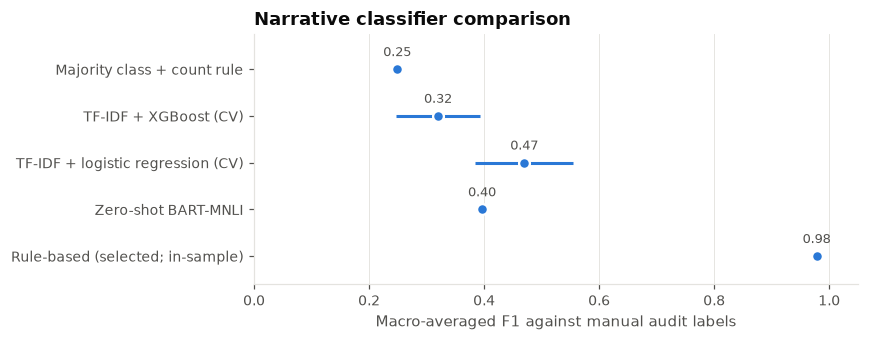

In [10]:
folds, pooled = nlp.cross_validate_models(df)
cv = folds.groupby("model")[["accuracy", "macro_F1", "kappa"]].agg(["mean", "std"])
base = nlp.majority_baseline(df)
rules = nlp._scores(df.manual_hazard, df.hazard)
zs = nlp.load_zeroshot(df)

rows = [{"method": "Majority class + count rule", "macro_F1": base["macro_F1"], "macro_F1_sd": np.nan,
         "accuracy": base["accuracy"], "kappa": base["kappa"]}]
for m in cv.index:
    rows.append({"method": m + " (CV)", "macro_F1": cv.loc[m, ("macro_F1", "mean")],
                 "macro_F1_sd": cv.loc[m, ("macro_F1", "std")], "accuracy": cv.loc[m, ("accuracy", "mean")],
                 "kappa": cv.loc[m, ("kappa", "mean")]})
if zs is not None:
    zz = df[["incident_id", "manual_hazard"]].merge(zs, on="incident_id")
    s = nlp._scores(zz.manual_hazard, zz.zs_hazard)
    rows.append({"method": "Zero-shot BART-MNLI", "macro_F1": s["macro_F1"], "macro_F1_sd": np.nan,
                 "accuracy": s["accuracy"], "kappa": s["kappa"]})
rows.append({"method": "Rule-based (selected; in-sample)", "macro_F1": rules["macro_F1"], "macro_F1_sd": np.nan,
             "accuracy": rules["accuracy"], "kappa": rules["kappa"]})
comp = pd.DataFrame(rows)
display(comp.round(3))
save_table(comp.round(3).fillna("—"), "tbl-classifiers",
           "Narrative classifiers scored against the manual audit labels (learned models: mean and SD over 4-fold x 5 repeated stratified CV).")

per_class = pd.DataFrame({m: nlp.per_class_f1(df.manual_hazard, p) for m, p in pooled.items()})
if zs is not None:
    per_class["Zero-shot BART-MNLI"] = nlp.per_class_f1(zz.manual_hazard, zz.zs_hazard)
per_class["Rule-based"] = nlp.per_class_f1(df.manual_hazard, df.hazard)
per_class.insert(0, "n (manual)", df.manual_hazard.value_counts().reindex(tx.HAZARD_CODES).values)
per_class.index = [HAZ_LABEL[c] for c in per_class.index]
display(per_class.round(2))
save_table(per_class.round(2).reset_index(names="Hazard"), "tbl-per-class-f1", "Per-class F1 by method.")

fig, _ = P.classifier_comparison_plot(comp)
save_fig(fig, "fig-classifiers"); plt.show()
lr = cv.loc["TF-IDF + logistic regression", ("macro_F1", "mean")]
xg = cv.loc["TF-IDF + XGBoost", ("macro_F1", "mean")]
save_vars({"lr_f1": r(lr), "xgb_f1": r(xg), "base_f1": r(base["macro_F1"]), "rule_f1": r(rules["macro_F1"]),
           "lr_h2_f1": r(per_class.iloc[1, 1]), "zs_f1": r(comp.set_index("method").macro_F1.get("Zero-shot BART-MNLI", np.nan))},
          "ml")

The learned models do only modestly better than predicting the majority
class. They score near zero on emergency obstruction, the rarest and
most consequential class, and those rare classes are what drive the risk
matrix. The zero-shot transformer needs no labels, but it does no better
than logistic regression (macro-F1 ≈ 0.40, accuracy ≈ 0.59).
General-purpose NLI models are not trained on dispatcher shorthand
(`blkng`, `ntfyd`, `LP`), and they over-assign dramatic classes such as
“collision”. The transparent rule set is the defensible choice at this
sample size. It is also easy to extend if a larger log becomes
available, and the manual labels can then serve as seed training data.

In [11]:
counts = df.hazard.value_counts().reindex(tx.HAZARD_CODES)
xt = pd.crosstab(df.hazard_name, df.cause_name).reindex([h.name for h in tx.HAZARDS])
display(xt)
save_table(xt.reset_index(names="Hazard"), "tbl-hazard-cause", "Hazard (consequence) by contributing cause (mechanism), all 123 incidents.")

PosixPath('/home/jon/Documents/grad_school/ai-risk/AV_Brick/project-site/assets/tables/tbl-hazard-cause.md')

Most narratives give no cause (“stalled”, “stuck”). That reflects the
sparse, truncated dispatcher text, and it is the main reason cause is
reported descriptively and not used to define hazards.

## 5. Impact (consequence) scoring

Each incident gets an impact level on the matrix’s 1–5 scale. The level
is the **maximum** over three components, so a single serious attribute
is never averaged away: the hazard-specific consequence, the duration
band, and the AV-cluster size. The rubric is written in
`av_blocking.severity`.

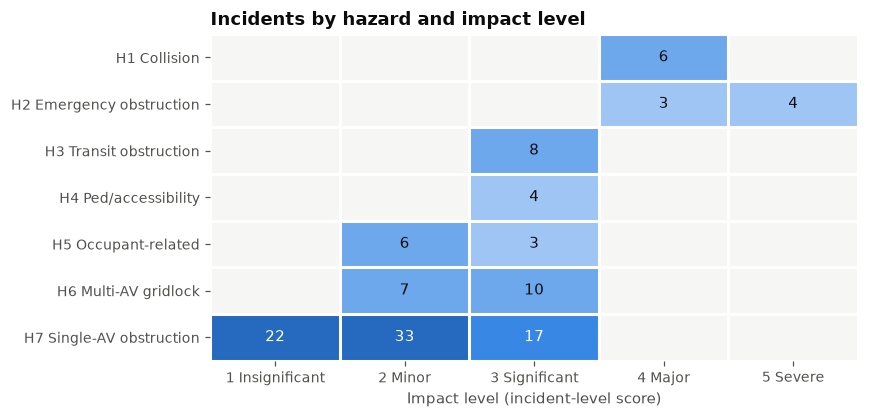

impact_driver
duration    63
hazard      55
cluster      5
Name: count, dtype: int64

In [12]:
rub = sv.rubric_table()
display(rub)
save_table(rub, "tbl-impact-rubric", "Incident-level impact rubric (the highest criterion met sets the level).")
hi = pd.crosstab(df.hazard, df.impact).reindex(index=tx.HAZARD_CODES, columns=range(1, 6), fill_value=0)
fig, _ = P.hazard_impact_heatmap(hi, [HAZ_LABEL[c] for c in tx.HAZARD_CODES],
                                 [f"{k} {sv.IMPACT_LABELS[k-1]}" for k in range(1, 6)])
save_fig(fig, "fig-hazard-impact"); plt.show()
print(df.impact_driver.value_counts())

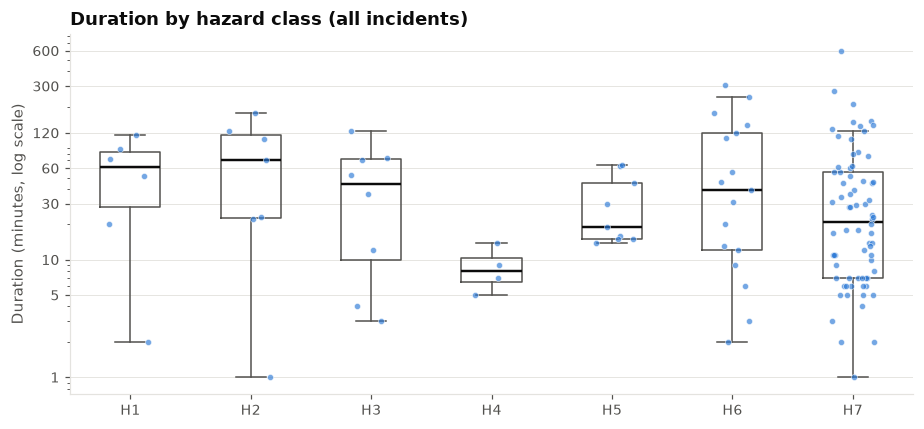

{'test': 'Kruskal-Wallis', 'H': 7.208584390177731, 'df': 6, 'p_value': 0.30198760320407253, 'epsilon_sq': 0.010418830949808026}

In [13]:
fig, _ = P.duration_by_group_plot(df, "hazard", tx.HAZARD_CODES, [c for c in tx.HAZARD_CODES],
                                  "Duration by hazard class (all incidents)")
save_fig(fig, "fig-duration-hazard"); plt.show()
kw_h = tr.kruskal_by(df.dropna(subset=["duration_min"]), "duration_min", "hazard", tx.HAZARD_CODES)
print(kw_h)
save_var("trend.kw_hazard_p", r(kw_h["p_value"], 3))

## 6. Frequency estimation

Incidents are modeled as a Poisson process with daily rate $\lambda$
over the $T = 184$ covered days. The analysis reports:

-   the MLE $\hat\lambda = n/T$ with an exact Garwood 95% CI;
-   the Jeffreys-prior posterior
    $\lambda \mid n \sim \mathrm{Gamma}(n + \tfrac12,\ T)$ with its 95%
    credible interval;
-   the posterior-predictive probability of at least one event in the
    next $h = 30$ days,
    $P(N_h \ge 1) = 1 - \left(\frac{T}{T+h}\right)^{n + 1/2}$.

The log has no exposure denominator (AV trips or miles), so rates are
**per calendar day**. They describe the San Francisco system as operated
in 2025, not per-mile safety.

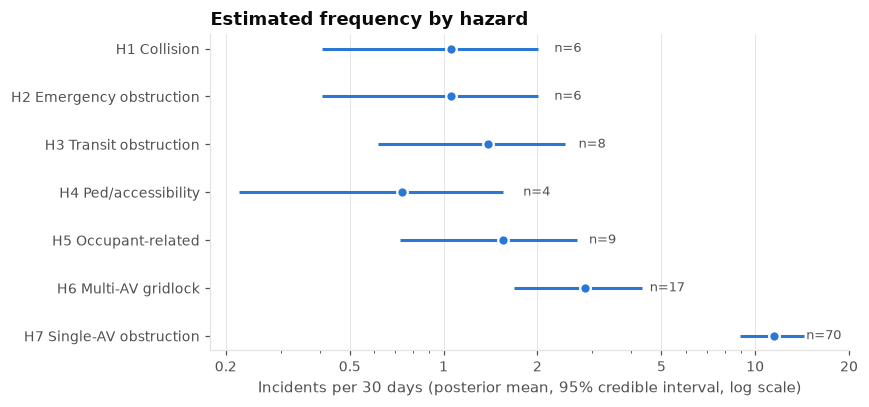

In [14]:
freq = fq.hazard_frequency_table(w, T)
show = freq[["hazard", "name", "n", "share", "rate_per_30d", "ci_lo_30d", "ci_hi_30d", "post_mean_30d",
             "cri_lo_30d", "cri_hi_30d", "mean_days_between", "p_any_horizon", "probability"]]
display(show.round(3))
tbl = show.assign(
    share=lambda d: d.share.map("{:.0%}".format),
    rate=lambda d: d.apply(lambda x: f"{x.rate_per_30d:.2f} ({x.ci_lo_30d:.2f}-{x.ci_hi_30d:.2f})", axis=1),
    post=lambda d: d.apply(lambda x: f"{x.post_mean_30d:.2f} ({x.cri_lo_30d:.2f}-{x.cri_hi_30d:.2f})", axis=1),
    every=lambda d: d.mean_days_between.map("{:.1f}".format),
    p=lambda d: d.p_any_horizon.map("{:.3f}".format),
)[["hazard", "name", "n", "share", "rate", "post", "every", "p", "probability"]]
tbl.columns = ["Code", "Hazard", "n", "Share", "MLE per 30 d (95% CI)", "Posterior per 30 d (95% CrI)",
               "Mean days between", "P(>=1 in 30 d)", "Band (all impacts)"]
save_table(tbl, "tbl-frequency", "Hazard frequencies over the 184 covered days (Mar, Jun-Oct 2025).")
tot = freq.set_index("hazard").loc["All"]
save_vars({"total_rate30": r(tot.rate_per_30d, 1), "total_lo": r(tot.ci_lo_30d, 1), "total_hi": r(tot.ci_hi_30d, 1),
           "days_between": r(tot.mean_days_between, 1), "per_week": r(tot.rate_per_30d / 30 * 7, 1)}, "freq")
for _, x in freq[freq.hazard != "All"].iterrows():
    save_vars({"n": int(x.n), "rate30": r(x.rate_per_30d), "every": r(x.mean_days_between, 0)}, f"freq.{x.hazard}")

fig, _ = P.hazard_rate_plot(freq, HAZ_LABEL)
save_fig(fig, "fig-hazard-rates"); plt.show()

## 7. Is anything changing over time?

Six monthly counts and about 120 skewed durations do not support
normal-theory tests. Each question is matched to a test whose
assumptions hold here.

### 7.1 Incident counts

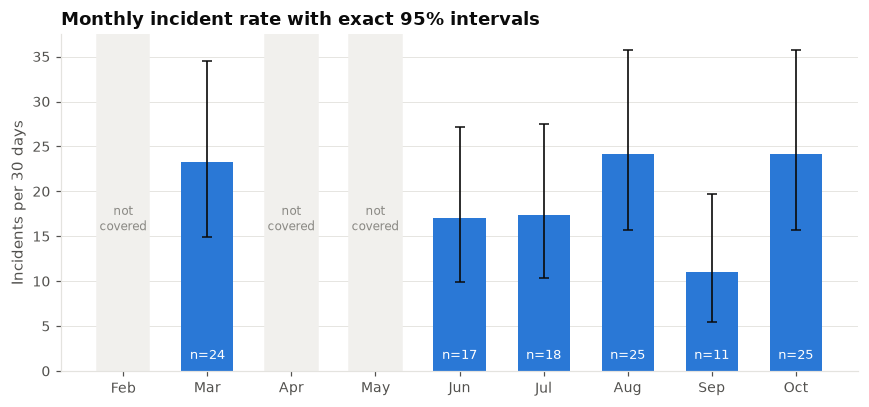

{'test': 'Poisson homogeneity (chi-square)', 'statistic': 7.299641577060934, 'df': 5, 'p_value': 0.1992922251810877}
{'test': 'Mann-Kendall', 'n': 6, 'S': 2.0, 'tau': 0.13333333333333333, 'z': np.float64(0.19127301391900148), 'p_normal': 0.8483117025202374, 'p_exact': 0.8555555555555555}
Sen slope (incidents/30d per month): 0.14
{'test': 'Exact conditional rate comparison', 'n1': 24, 'n2': 25, 'rate_ratio': 1.0416666666666667, 'rr_ci_lo': np.float64(0.5707914672791645), 'rr_ci_hi': np.float64(1.9048873947430458), 'p_value': 1.0}

In [15]:
mc = tr.monthly_counts(w, days)
ci = pd.DataFrame([fq.garwood_ci(n, d) for n, d in zip(mc.n, mc.days)], index=mc.index, columns=["lo", "hi"]) * 30
all_months = [str(p) for p in pd.period_range("2025-02", "2025-10", freq="M")]
fig, _ = P.monthly_rate_plot(mc, ci, all_months)
save_fig(fig, "fig-monthly-rate"); plt.show()

rate = (mc.n / mc.days).values
disp = tr.dispersion_test(mc.n, mc.days)
mk = tr.mann_kendall(rate)
sen = tr.sen_slope(rate * 30, mc.t)
mo = tr.exact_rate_comparison(int(mc.n.iloc[0]), 31, int(mc.n.iloc[-1]), 31)
glm = tr.count_glms(mc)
print(disp); print(mk); print("Sen slope (incidents/30d per month):", round(sen, 2)); print(mo)
display(glm.round(4))

### 7.2 Durations

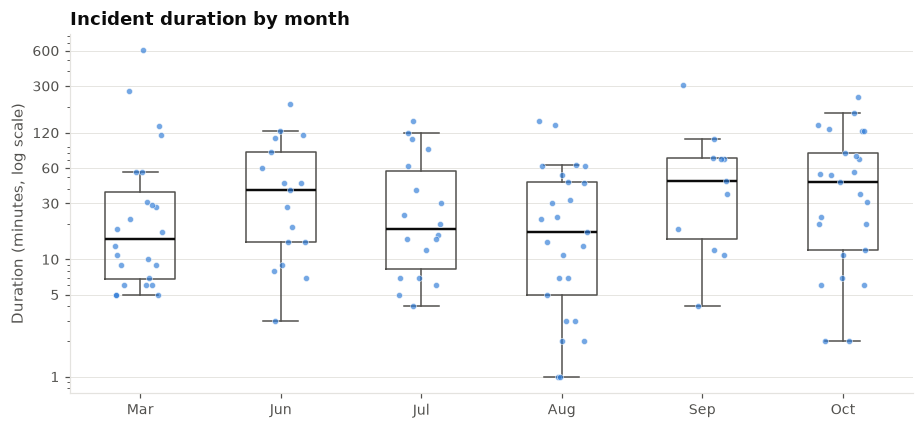

Kruskal-Wallis: {'test': 'Kruskal-Wallis', 'H': 6.884256507950153, 'df': 5, 'p_value': 0.2293916032884925, 'epsilon_sq': 0.016528565859211867}
Mann-Whitney Mar vs Oct: {'test': 'Mann-Whitney U', 'n1': 24, 'n2': 25, 'U': 222.5, 'p_value': 0.12323467768639308, 'rank_biserial': 0.2583333333333333, 'prob_superiority': 0.37083333333333335}
Replication without the 603-min outlier: U(Oct) = 377.5 p = 0.0645
Jonckheere-Terpstra: {'test': 'Jonckheere-Terpstra', 'JT': 3248.0, 'expected': 2960.0, 'z': 1.3242970930191955, 'p_value': 0.18589070546472677}
{'test': 'Spearman (duration vs date)', 'rho': 0.09717863061330638, 'p_value': 0.29101500650720047, 'theil_sen_pct_per_30d': 5.333591976411035, 'ts_lo_pct': -5.065471548094056, 'ts_hi_pct': 16.811511667700714}
Welch t on log durations Mar vs Oct: p = 0.245

In [16]:
order = list(days.index)
fig, _ = P.duration_by_group_plot(w, "month", order, [pd.Period(m).strftime("%b") for m in order],
                                  "Incident duration by month")
save_fig(fig, "fig-duration-month"); plt.show()

kw = tr.kruskal_by(w, "duration_min", "month", order)
mar = w.loc[w.month == "2025-03", "duration_min"]; octo = w.loc[w.month == "2025-10", "duration_min"]
mw = tr.mann_whitney(mar, octo)
# Replication of the instructor's sheet, which omitted the 603-minute Mar-12 record
mw_rep = tr.mann_whitney(mar[mar < 600], octo)
print("Kruskal-Wallis:", kw)
print("Mann-Whitney Mar vs Oct:", mw)
print("Replication without the 603-min outlier: U(Oct) =", 23 * 25 - mw_rep["U"], "p =", round(mw_rep["p_value"], 4))
jt = tr.jonckheere_terpstra([w.loc[w.month == m, "duration_min"].values for m in order])
print("Jonckheere-Terpstra:", jt)
dt_ = tr.duration_vs_time(w)
print(dt_)
# parametric cross-check on log scale (log-durations ~ normal)
from scipy import stats
print("Welch t on log durations Mar vs Oct: p =", round(stats.ttest_ind(np.log(mar), np.log(octo), equal_var=False).pvalue, 3))

### 7.3 Hazard mix and reporting artifacts

Hazard x period: {'test': 'Permutation chi-square', 'chi2': 16.42529087211434, 'p_value': 0.007149642517874106, 'share_expected_lt5': 0.7142857142857143}

Truncated narratives by period:
 narrative_truncated  False  True 
period                           
Mar-Jul                  1     58
Aug-Oct                 36     25 
Fisher exact p = 4.982960875292966e-13
Median narrative length: {'Aug-Oct': 81.0, 'Mar-Jul': 50.0}
Text-dependent hazards (H1-H5) by period:
 hazard   False  True 
period               
Mar-Jul     46     13
Aug-Oct     41     20 
Fisher p = 0.22255362680504995
Multi-AV share trend (count field, not text): {'test': 'Cochran-Armitage', 'z': 1.3747338148189274, 'p_value': 0.16921398374150942}

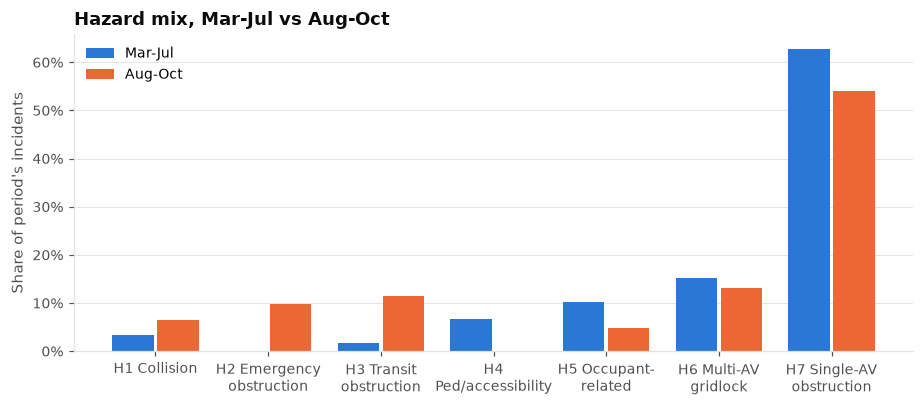

In [17]:
w["period"] = np.where(w.date < "2025-08-01", "Mar-Jul", "Aug-Oct")
mix = tr.permutation_chi2(w.hazard, w.period)
print("Hazard x period:", mix)
shares = pd.crosstab(w.hazard, w.period, normalize="columns")[["Mar-Jul", "Aug-Oct"]].reindex(tx.HAZARD_CODES)
display(pd.crosstab(w.hazard, w.period)[["Mar-Jul", "Aug-Oct"]])

trunc_tab = pd.crosstab(w.period, w.narrative_truncated).loc[["Mar-Jul", "Aug-Oct"]]
trunc = stats.fisher_exact(trunc_tab.values)
print("Truncated narratives by period:\n", trunc_tab, "\nFisher exact p =", trunc.pvalue)
mean_len = w.groupby("period")["narrative"].apply(lambda s: s.str.len().median())
print("Median narrative length:", mean_len.to_dict())

textual = w.hazard.isin(["H1", "H2", "H3", "H4", "H5"])
tx_tab = pd.crosstab(w.period, textual).loc[["Mar-Jul", "Aug-Oct"]]
tx_p = stats.fisher_exact(tx_tab.values).pvalue
print("Text-dependent hazards (H1-H5) by period:\n", tx_tab, "\nFisher p =", tx_p)

mca = tr.monthly_counts(w, days, "multi_av")
ca = tr.cochran_armitage(mca[True], mca[True] + mca[False], mca.t)
print("Multi-AV share trend (count field, not text):", ca)

fig, _ = P.grouped_share_plot(shares, [HAZ_LABEL[c] for c in tx.HAZARD_CODES],
                              "Hazard mix, Mar-Jul vs Aug-Oct", "Share of period's incidents")
save_fig(fig, "fig-hazard-period"); plt.show()

The hazard mix *does* differ between periods (permutation p ≈ 0.007).
But the change is a reshuffle *within* the text-dependent classes. H2
(emergency) and H3 (transit) appear almost only from August on, while H4
and H5 were more common earlier. The combined share of H1–H5 does not
differ (Fisher p ≈ 0.22). The narratives changed at the same moment: 98%
of Mar–Jul narratives are truncated fragments (median 50 characters),
against 41% for Aug–Oct (median 81). Context such as “fire”, “medic”, or
“Muni” is exactly what a 50-character fragment loses. The one
composition measure that comes from a structured field, the multi-AV
share, shows no trend (Cochran–Armitage p ≈ 0.17). The defensible
conclusion is that the observed shift is **not attributable** to a
change in AV behavior. It is most plausibly a reporting/recording
artifact.

In [18]:
tests = pd.DataFrame([
    ["Monthly incident rate", "Equal rate across months", "Poisson homogeneity chi-square",
     f"chi2({disp['df']}) = {disp['statistic']:.2f}", disp["p_value"]],
    ["Monthly incident rate", "No monotone trend", "Mann-Kendall (exact)",
     f"S = {mk['S']:.0f}, tau = {mk['tau']:.2f}", mk["p_exact"]],
    ["Monthly incident rate", "Mar rate = Oct rate", "Exact conditional binomial",
     f"RR = {mo['rate_ratio']:.2f} ({mo['rr_ci_lo']:.2f}-{mo['rr_ci_hi']:.2f})", mo["p_value"]],
    ["Monthly incident rate", "No log-linear trend", "Poisson GLM, log(days) offset",
     f"RR/month = {glm.rate_ratio_per_month[0]:.3f} ({glm.ci_lo[0]:.3f}-{glm.ci_hi[0]:.3f})", glm.p_value[0]],
    ["Duration", "Same distribution in all months", "Kruskal-Wallis",
     f"H({kw['df']}) = {kw['H']:.2f}, eps2 = {kw['epsilon_sq']:.3f}", kw["p_value"]],
    ["Duration", "Mar = Oct", "Mann-Whitney U", f"U = {mw['U']:.1f}, r_rb = {mw['rank_biserial']:.2f}", mw["p_value"]],
    ["Duration", "Mar = Oct (603-min record dropped, replicates class sheet)", "Mann-Whitney U",
     f"W = {23 * 25 - mw_rep['U']:.1f}", mw_rep["p_value"]],
    ["Duration", "No ordered shift across months", "Jonckheere-Terpstra (permutation)",
     f"JT = {jt['JT']:.0f}, z = {jt['z']:.2f}", jt["p_value"]],
    ["Duration", "No association with date", "Spearman; Theil-Sen on log duration",
     f"rho = {dt_['rho']:.2f}; {dt_['theil_sen_pct_per_30d']:+.1f}%/30 d ({dt_['ts_lo_pct']:+.1f} to {dt_['ts_hi_pct']:+.1f})",
     dt_["p_value"]],
    ["Hazard mix", "Independent of period", "Permutation chi-square", f"chi2 = {mix['chi2']:.2f}", mix["p_value"]],
    ["Narrative truncation", "Independent of period", "Fisher exact",
     f"{trunc_tab.loc['Mar-Jul', True] / trunc_tab.loc['Mar-Jul'].sum():.0%} vs {trunc_tab.loc['Aug-Oct', True] / trunc_tab.loc['Aug-Oct'].sum():.0%} truncated", trunc.pvalue],
    ["Text-dependent hazards (H1-H5) share", "Independent of period", "Fisher exact",
     f"{tx_tab.loc['Mar-Jul', True] / tx_tab.loc['Mar-Jul'].sum():.0%} vs {tx_tab.loc['Aug-Oct', True] / tx_tab.loc['Aug-Oct'].sum():.0%}", tx_p],
    ["Multi-AV share", "No monotone trend", "Cochran-Armitage", f"z = {ca['z']:.2f}", ca["p_value"]],
], columns=["Quantity", "Null hypothesis", "Test", "Statistic / effect", "p"])
tests["Reject at 0.05?"] = np.where(tests.p < 0.05, "Yes", "No")
tests["p"] = tests.p.map(fmt_p)
display(tests)
save_table(tests, "tbl-tests", "Statistical tests for change over time (covered months).")
save_vars({"disp_p": r(disp["p_value"], 2), "mk_p": r(mk["p_exact"], 2), "mk_tau": r(mk["tau"], 2),
           "mo_rr": r(mo["rate_ratio"]), "mo_lo": r(mo["rr_ci_lo"]), "mo_hi": r(mo["rr_ci_hi"]), "mo_p": r(mo["p_value"], 2),
           "glm_rr": r(glm.rate_ratio_per_month[0], 3), "glm_lo": r(glm.ci_lo[0], 3), "glm_hi": r(glm.ci_hi[0], 3),
           "glm_p": r(glm.p_value[0], 2), "glm_disp": r(glm.pearson_dispersion[0], 2),
           "kw_H": r(kw["H"]), "kw_p": r(kw["p_value"], 2), "mw_p": r(mw["p_value"], 3),
           "mw_rep_W": float(23 * 25 - mw_rep["U"]), "mw_rep_p": r(mw_rep["p_value"], 3),
           "jt_p": r(jt["p_value"], 2), "rho": r(dt_["rho"]), "rho_p": r(dt_["p_value"], 2),
           "ts_pct": r(dt_["theil_sen_pct_per_30d"], 1), "ts_lo": r(dt_["ts_lo_pct"], 1), "ts_hi": r(dt_["ts_hi_pct"], 1),
           "mix_p": r(mix["p_value"], 3), "tx_p": r(tx_p, 2), "trunc_p": fmt_p(trunc.pvalue), "ca_p": r(ca["p_value"], 2),
           "trunc_early": f"{trunc_tab.loc['Mar-Jul', True] / trunc_tab.loc['Mar-Jul'].sum():.0%}",
           "trunc_late": f"{trunc_tab.loc['Aug-Oct', True] / trunc_tab.loc['Aug-Oct'].sum():.0%}"}, "trend")

## 8. Risk matrix

**Probability band.** $p = P(N_{30} \ge 1)$ from the posterior
predictive above, banded with the template’s edges: Rare \< 0.05 ≤
Unlikely \< 0.25 ≤ Moderate \< 0.50 ≤ Likely \< 0.90 ≤ Almost certain.

**Impact and placement (risk curve).** For hazard $h$ and impact tier
$k$, count $n_{h,\ge k}$, the incidents of $h$ with impact $\ge k$. Each
observed tier yields a candidate cell
$\big(\text{band}(n_{h,\ge k}),\,k\big)$. The hazard sits in the
candidate cell with the highest template risk level (ties go to the
higher impact). Probability and impact then describe the same event (“an
$h$ incident of at least impact $k$”). Only tiers that actually occurred
are considered.

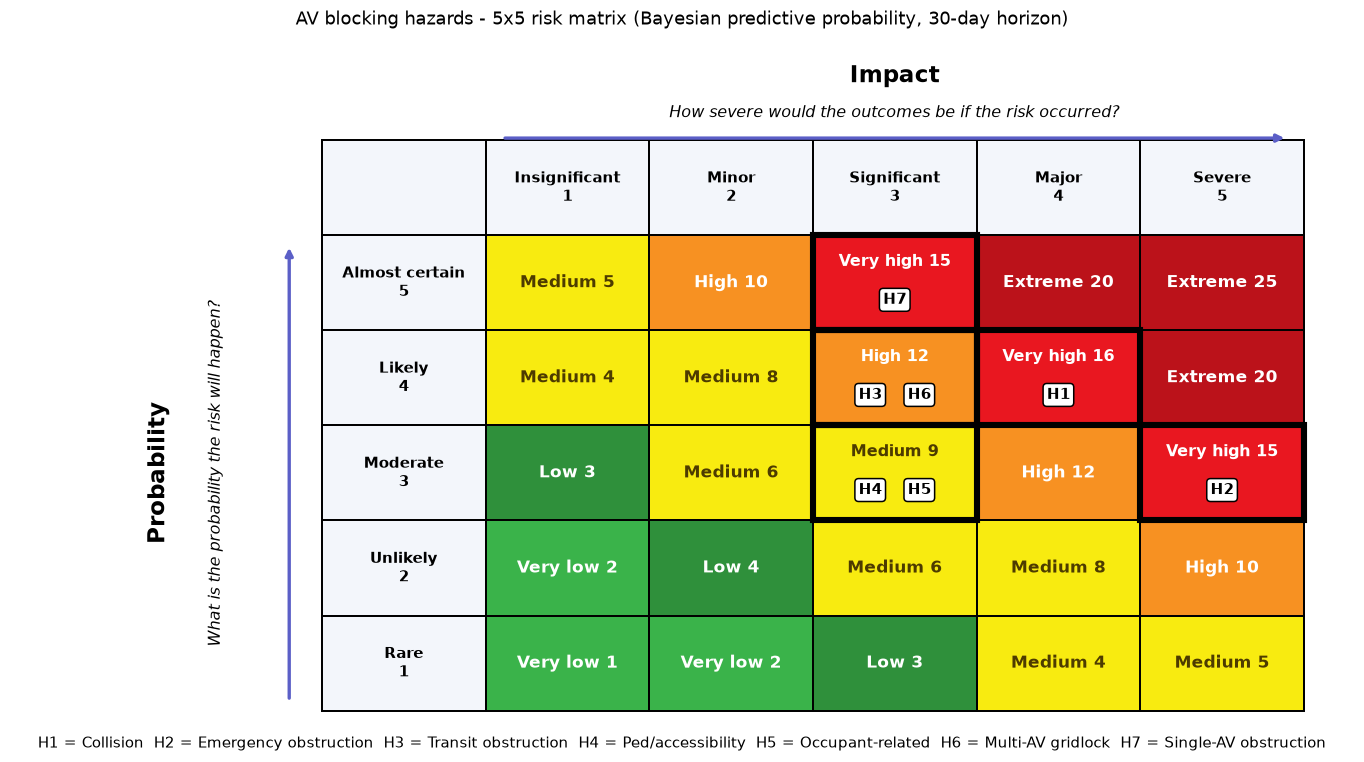

In [19]:
curves = pd.concat([fq.risk_curve(w, h, T) for h in tx.HAZARD_CODES])
curves_tbl = curves.assign(p_any=curves.p_any.round(3),
                           prob=curves.prob.map(lambda b: rm.PROB_LABELS[b - 1]),
                           impact=curves.impact.map(lambda k: f"{k} {sv.IMPACT_LABELS[k-1]}"))
curves_tbl.columns = ["Hazard", "Impact tier k", "n with impact >= k", "P(>=1 in 30 d)", "Probability", "Risk level"]
display(curves_tbl)
save_table(curves_tbl, "tbl-risk-curves", "Risk-curve candidates: each observed impact tier with its own frequency and risk level.")

placed = fq.place_hazards(w, T)
display(placed)
pt = placed.assign(p=placed.p_any_horizon.map("{:.2f}".format),
                   prob=placed.apply(lambda x: f"{x.prob} {x.prob_label}", axis=1),
                   imp=placed.apply(lambda x: f"{x.governing_impact} {x.impact_label}", axis=1),
                   lvl=placed.apply(lambda x: f"{x.level} ({x.score})", axis=1))[
    ["hazard", "name", "n", "n_at_or_above", "p", "prob", "imp", "lvl"]]
pt.columns = ["Code", "Hazard", "n", "n at governing impact", "P(>=1 in 30 d)", "Probability", "Impact", "Risk level (score)"]
save_table(pt, "tbl-risk-placement", "Risk-matrix placement of each hazard (Bayesian predictive probability, 30-day horizon).")
for x in placed.itertuples():
    save_vars({"level": x.level, "prob": x.prob_label, "impact": x.impact_label, "score": x.score,
               "n_ge": x.n_at_or_above, "p": r(x.p_any_horizon, 2)}, f"risk.{x.hazard}")

fig, _ = rm.plot_risk_matrix(fq.to_placements(placed),
                             title="AV blocking hazards - 5x5 risk matrix (Bayesian predictive probability, 30-day horizon)",
                             footnote="  ".join(f"{h.code} = {h.short}" for h in tx.HAZARDS))
save_fig(fig, "fig-risk-matrix"); plt.show()

## 9. Sensitivity analysis

How far do the placements move under reasonable alternative choices?

-   **Probability basis**: plug-in MLE instead of the Bayesian
    predictive.
-   **Horizon**: 7 or 90 days instead of 30.
-   **Exposure window**: include February. This treats Feb 1–Mar 31 and
    Jun 1–Oct 31 as observed (212 days, all 123 incidents).
-   **Supplementary incidents**: add the analyzed-sheet incidents that
    have a narrative but no times. They are classified by the same rules
    and given impact from hazard and AV count only.
-   **Placement rule**: the conventional pairing of total hazard
    frequency with the 90th-percentile impact.

In [20]:
def cell(p):
    return p.set_index("hazard").apply(lambda x: f"{x.prob}x{x.governing_impact} {x.level}", axis=1)

sens = pd.DataFrame({"Base (Bayesian, 30 d, covered months)": cell(placed)})
sens["Plug-in MLE"] = cell(fq.place_hazards(w, T, basis="per_period"))
sens["7-day horizon"] = cell(fq.place_hazards(w, T, horizon=7))
sens["90-day horizon"] = cell(fq.place_hazards(w, T, horizon=90))
sens["Include February (212 d)"] = cell(fq.place_hazards(df, 212.0))

sp = supp.copy()
sp["in_covered_window"] = sp.month.isin(config.COVERED_MONTHS)
sp["hazard"] = [tx.classify_hazard(t, n) for t, n in zip(sp.narrative, sp.n_avs_filled)]
sp["impact"] = [max(sv.hazard_score(h, t), sv.cluster_score(n)) for h, t, n in zip(sp.hazard, sp.narrative, sp.n_avs_filled)]
w_plus = pd.concat([w[["hazard", "impact"]], sp.loc[sp.in_covered_window, ["hazard", "impact"]]])
sens["+ supplementary incidents"] = cell(fq.place_hazards(w_plus, T))
conv = fq.conventional_placement(w, T).set_index("hazard")
sens["Total freq x P90 impact"] = conv.apply(lambda x: f"{x.prob}x{x.impact} {x.level}", axis=1)
sens.index = [HAZ_LABEL[c] for c in sens.index]
display(sens)
save_table(sens.reset_index(names="Hazard"), "tbl-sensitivity",
           "Sensitivity of risk-matrix placement (cell shown as probability x impact and level).")
print(sp[["date", "hazard", "impact", "narrative"]])

        date hazard  impact                                                                                                      narrative
0 2025-02-01     H4       3  Req from CHP to have SFPD resp to assist with removing disabled Waymo AV that is completely blocking the r...
1 2025-08-15     H7       1  RP reporting an unoccpyd Zoox AV driving erratically, had its left turn signal on but kept turning right a...
2 2025-10-15     H7       1                                                           Waymo blking traffic rep on 911 txd to 0123 non-emer
3 2025-10-16     H7       1                                                               Waymo AV drove into the middle of active 518 H/R
4 2025-10-20     H3       3                                                          Two Muni Coaches stuck in traffic per RP it is due to
5 2025-10-22     H2       4                                                            Multi veh inj accident Waymo AV drove into the scen
6 2025-10-31     H7       1

**How to read the sensitivity table.**

-   **Robust to data choices.** Placements do not move under the MLE
    basis, when February is included, or when the supplementary
    incidents are added.
-   **The horizon sets the absolute level.** A 7-day horizon lowers
    every hazard one or two bands; a 90-day horizon raises them. The
    horizon is a *policy* choice: 30 days matches a monthly
    operations-review cycle. The *ranking* is stable: under every
    column, H2 is at (or tied for) the highest level, and H4 and H5 are
    at (or tied for) the lowest.
-   **The placement rule matters for H2.** The conventional “total
    frequency × P90 impact” rule puts H2 at *Extreme*. That pairs H2’s
    overall frequency (6 events) with its rarer life-threatening tier (3
    events), which overstates the probability of the Severe outcome. The
    risk-curve method avoids that inconsistency, which is why it is the
    base case.

In [21]:
headline = (
    f"Over {int(T)} covered days the DEM log records {len(w)} AV blocking incidents, about "
    f"{tot.rate_per_30d:.1f} per 30 days (one every {tot.mean_days_between:.1f} days). "
    f"Neither the incident rate nor incident duration shows a statistically significant trend. "
    f"On the risk matrix, " + "; ".join(f"{x.hazard} ({x.name}) is **{x.level}**" for x in placed.itertuples()) + "."
)
save_text(headline, "headline")
display(Markdown(headline))